# Saliency Analysis of DP-VAE Synthetic MNIST Images

**Goal:** Use Explainable AI (Integrated Gradients + Grad-CAM) to visualize which pixels
in synthetic images retain useful class information under different privacy budgets.

**Setup:**
1. Train a CNN classifier on **real** MNIST (high accuracy baseline)
2. Generate synthetic images: `n_real=600`, conditions: no-DP, ε=1, ε=8
3. Run saliency methods on real + synthetic images
4. Compare: real → no-DP → ε=8 → ε=1 degradation

In [1]:
from pathlib import Path
import sys
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from captum.attr import IntegratedGradients, LayerGradCam

ROOT = Path.cwd()
if not (ROOT / "models").exists() and (ROOT.parent / "models").exists():
    ROOT = ROOT.parent
if not (ROOT / "models").exists() and (ROOT.parent.parent / "models").exists():
    ROOT = ROOT.parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.mnist.mnist_cnn import MNIST_CNN
from models.mnist.train_mnist_vae import train_mnist_vae_dp

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

<repo>/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 1. Load Real MNIST & Train Classifier

In [2]:
IMG_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

mnist_train = datasets.MNIST(root=ROOT / "data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root=ROOT / "data", train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=256, shuffle=False)

print(f"Train: {len(mnist_train)}, Test: {len(mnist_test)}")

Train: 60000, Test: 10000


In [3]:
# Train classifier on real MNIST (5 epochs is enough for ~99%)
clf = MNIST_CNN().to(device)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-3)

clf.train()
for epoch in range(5):
    correct, total = 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = F.cross_entropy(clf(x), y)
        loss.backward()
        optimizer.step()
        correct += (clf(x).argmax(1) == y).sum().item()
        total += y.size(0)
    print(f"Epoch {epoch+1}/5 — train acc: {correct/total:.4f}")

# Evaluate
clf.eval()
correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        correct += (clf(x).argmax(1) == y).sum().item()
        total += y.size(0)
print(f"\nTest accuracy: {correct/total:.4f}")

Epoch 1/5 — train acc: 0.9471
Epoch 2/5 — train acc: 0.9902
Epoch 3/5 — train acc: 0.9938
Epoch 4/5 — train acc: 0.9952
Epoch 5/5 — train acc: 0.9972

Test accuracy: 0.9888


## 2. Generate Synthetic Images (n_real=600)

In [4]:
from opacus.accountants.utils import get_noise_multiplier

# Build real data pool
all_images = torch.stack([mnist_train[i][0] for i in range(len(mnist_train))])
all_labels = torch.tensor([mnist_train[i][1] for i in range(len(mnist_train))], dtype=torch.long)

real_by_label = {}
for lbl in range(10):
    real_by_label[lbl] = all_images[all_labels == lbl]

N_REAL = 600
BATCH_SIZE = 64
EPOCHS = 50
LATENT_DIM = 20
DELTA = 1e-5

# Subsample n_real per label
sub_imgs, sub_lbls = [], []
for lbl in range(10):
    pool = real_by_label[lbl]
    perm = torch.randperm(pool.shape[0])[:N_REAL]
    sub_imgs.append(pool[perm])
    sub_lbls.append(torch.full((N_REAL,), lbl, dtype=torch.long))
data_tensor = torch.cat(sub_imgs, dim=0)
label_tensor = torch.cat(sub_lbls, dim=0)

def get_noise_mult(target_eps):
    if target_eps is None:
        return 0.0
    sr = min(BATCH_SIZE / N_REAL, 0.99)
    return float(get_noise_multiplier(
        target_epsilon=float(target_eps), target_delta=DELTA,
        sample_rate=sr, epochs=EPOCHS,
    ))

CONDITIONS = [
    ("no-DP", None),
    ("ε=8", 8.0),
    ("ε=1", 1.0),
]

synthetic_cache = {}
for label, target_eps in CONDITIONS:
    nm = get_noise_mult(target_eps)
    print(f"\n{'='*50}")
    print(f"Generating: {label} (noise_multiplier={nm:.4f})")
    print(f"{'='*50}")
    syn_x, syn_y, metrics, eps_per_label = train_mnist_vae_dp(
        data_tensor=data_tensor, label_tensor=label_tensor,
        epochs=EPOCHS, batch_size=BATCH_SIZE, latent_dim=LATENT_DIM,
        noise_multiplier=nm, max_grad_norm=1.0, kl_warmup=10,
        lr=1e-3, delta=DELTA, img_size=IMG_SIZE,
        scale_syn=False, synthetic_count=200, seed=SEED,
    )
    synthetic_cache[label] = (syn_x, syn_y)
    print(f"  alpha_prec={metrics['alpha_precision']:.4f}, beta_rec={metrics['beta_recall']:.4f}")

print("\nDone generating all conditions.")


Generating: no-DP (noise_multiplier=0.0000)
[MNIST-DP-FedAug] Found labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[MNIST-DP-FedAug] Label 0: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 0 complete. ε=∞
[MNIST-DP-FedAug] Label 1: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 1 complete. ε=∞
[MNIST-DP-FedAug] Label 2: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 2 complete. ε=∞
[MNIST-DP-FedAug] Label 3: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 3 complete. ε=∞
[MNIST-DP-FedAug] Label 4: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 4 complete. ε=∞
[MNIST-DP-FedAug] Label 5: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 5 complete. ε=∞
[MNIST-DP-FedAug] Label 6: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 6 complete. ε=∞
[MNIST-DP-FedAug] Label 7: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 7 complete. ε=∞
[MNIST-DP-FedAug] Label 8: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 8 complete. ε=∞
[MNIST-DP-FedAug] Label 9: 600 real -> 200 synthetic
[M

<repo>/.venv/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


[MNIST-DP-FedAug] Label 0 complete. ε=7.10
[MNIST-DP-FedAug] Label 1: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 1 complete. ε=7.10
[MNIST-DP-FedAug] Label 2: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 2 complete. ε=7.10
[MNIST-DP-FedAug] Label 3: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 3 complete. ε=7.10
[MNIST-DP-FedAug] Label 4: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 4 complete. ε=7.10
[MNIST-DP-FedAug] Label 5: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 5 complete. ε=7.10
[MNIST-DP-FedAug] Label 6: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 6 complete. ε=7.10
[MNIST-DP-FedAug] Label 7: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 7 complete. ε=7.10
[MNIST-DP-FedAug] Label 8: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 8 complete. ε=7.10
[MNIST-DP-FedAug] Label 9: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 9 complete. ε=7.10
  alpha_prec=0.0000, beta_rec=0.0000

Generating: ε=1 (noise_multiplier=9.4531)
[MNIST-DP-Fed

<repo>/.venv/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
<repo>/.venv/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


[MNIST-DP-FedAug] Label 0 complete. ε=0.89
[MNIST-DP-FedAug] Label 1: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 1 complete. ε=0.89
[MNIST-DP-FedAug] Label 2: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 2 complete. ε=0.89
[MNIST-DP-FedAug] Label 3: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 3 complete. ε=0.89
[MNIST-DP-FedAug] Label 4: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 4 complete. ε=0.89
[MNIST-DP-FedAug] Label 5: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 5 complete. ε=0.89
[MNIST-DP-FedAug] Label 6: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 6 complete. ε=0.89
[MNIST-DP-FedAug] Label 7: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 7 complete. ε=0.89
[MNIST-DP-FedAug] Label 8: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 8 complete. ε=0.89
[MNIST-DP-FedAug] Label 9: 600 real -> 200 synthetic
[MNIST-DP-FedAug] Label 9 complete. ε=0.89
  alpha_prec=0.0000, beta_rec=0.0000

Done generating all conditions.


## 3. Saliency Helpers

In [5]:
# Integrated Gradients
ig = IntegratedGradients(clf)

# Grad-CAM on last conv layer (conv2_2)
gradcam = LayerGradCam(clf, clf.conv2_2)


def compute_ig(img_tensor, target_label):
    """Compute Integrated Gradients attribution for a single image."""
    img = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    baseline = torch.zeros_like(img)
    attr = ig.attribute(img, baselines=baseline, target=target_label, n_steps=50)
    # Squeeze to (H, W) and take absolute value
    return attr.squeeze().detach().cpu().abs().numpy()


def compute_gradcam(img_tensor, target_label):
    """Compute Grad-CAM attribution for a single image."""
    img = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
    attr = gradcam.attribute(img, target=target_label)
    # Upsample to image size
    attr = F.interpolate(attr, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    attr = attr.squeeze().detach().cpu()
    attr = F.relu(attr)  # Only positive activations
    return attr.numpy()


def normalize_attr(attr):
    """Min-max normalize attribution map to [0, 1]."""
    vmin, vmax = attr.min(), attr.max()
    if vmax - vmin < 1e-8:
        return np.zeros_like(attr)
    return (attr - vmin) / (vmax - vmin)

## 4. Saliency Comparison Grid

For selected digits, show:
- Row per condition: Real | no-DP | ε=8 | ε=1
- Columns: original image, IG overlay, Grad-CAM overlay

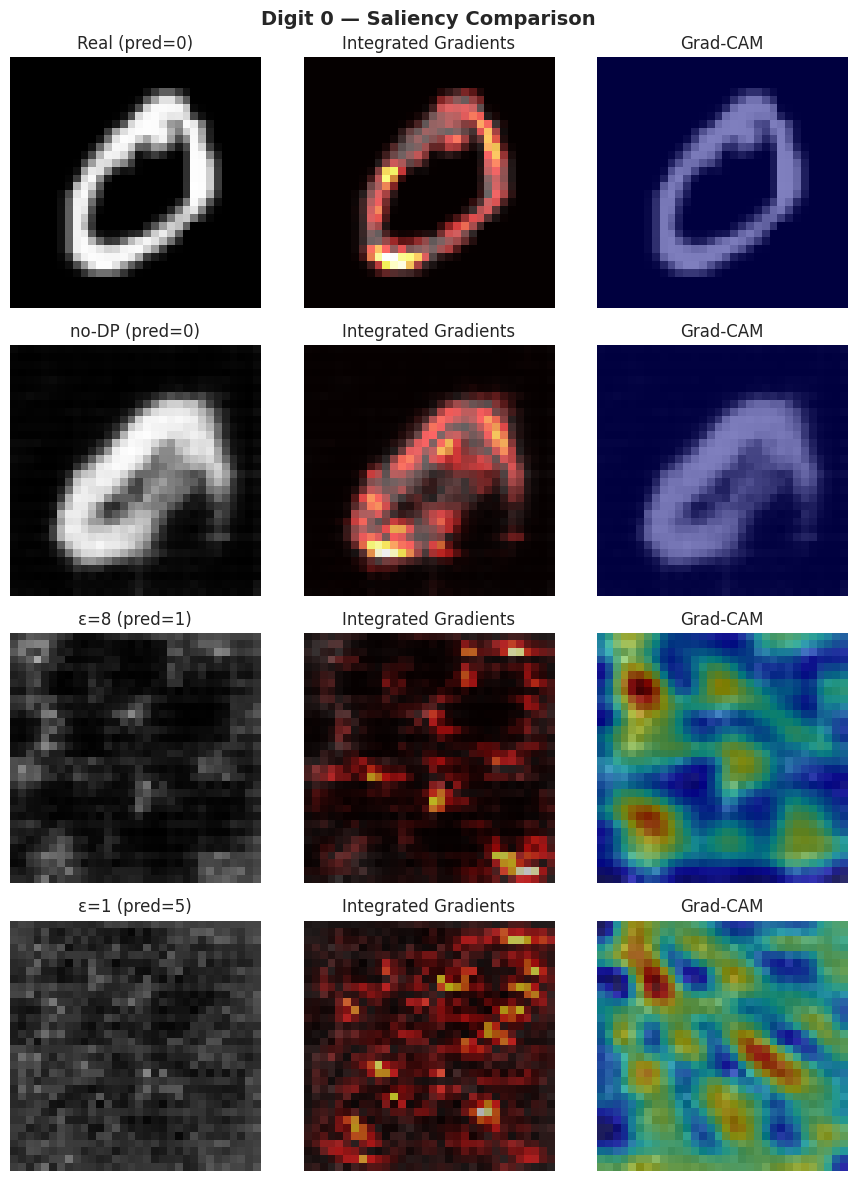

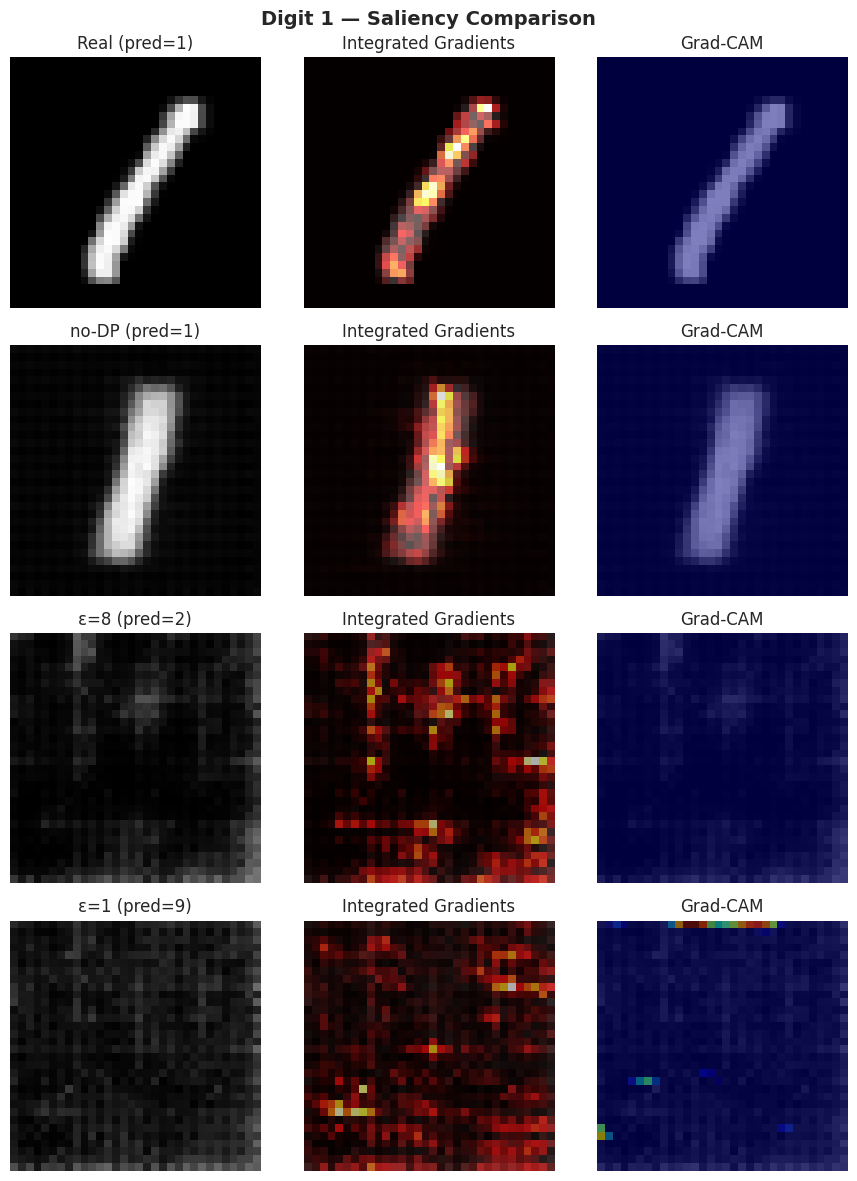

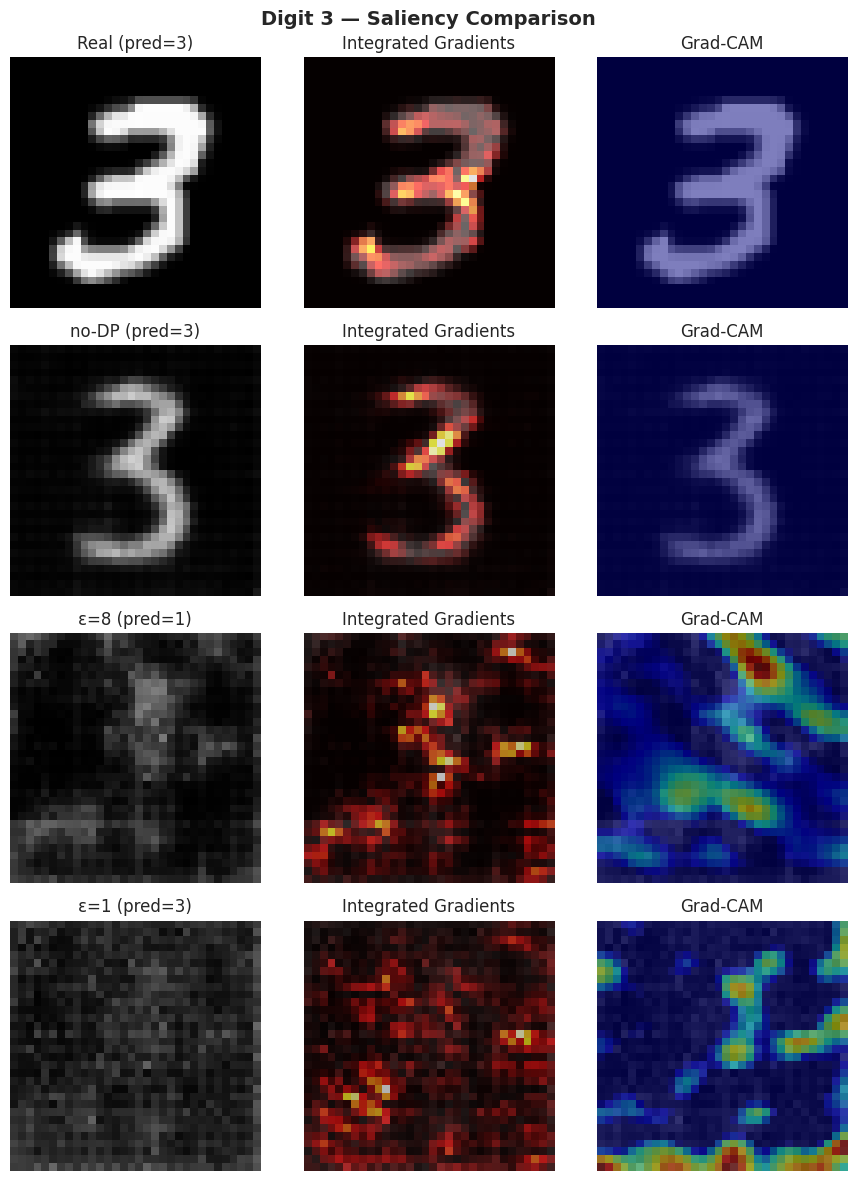

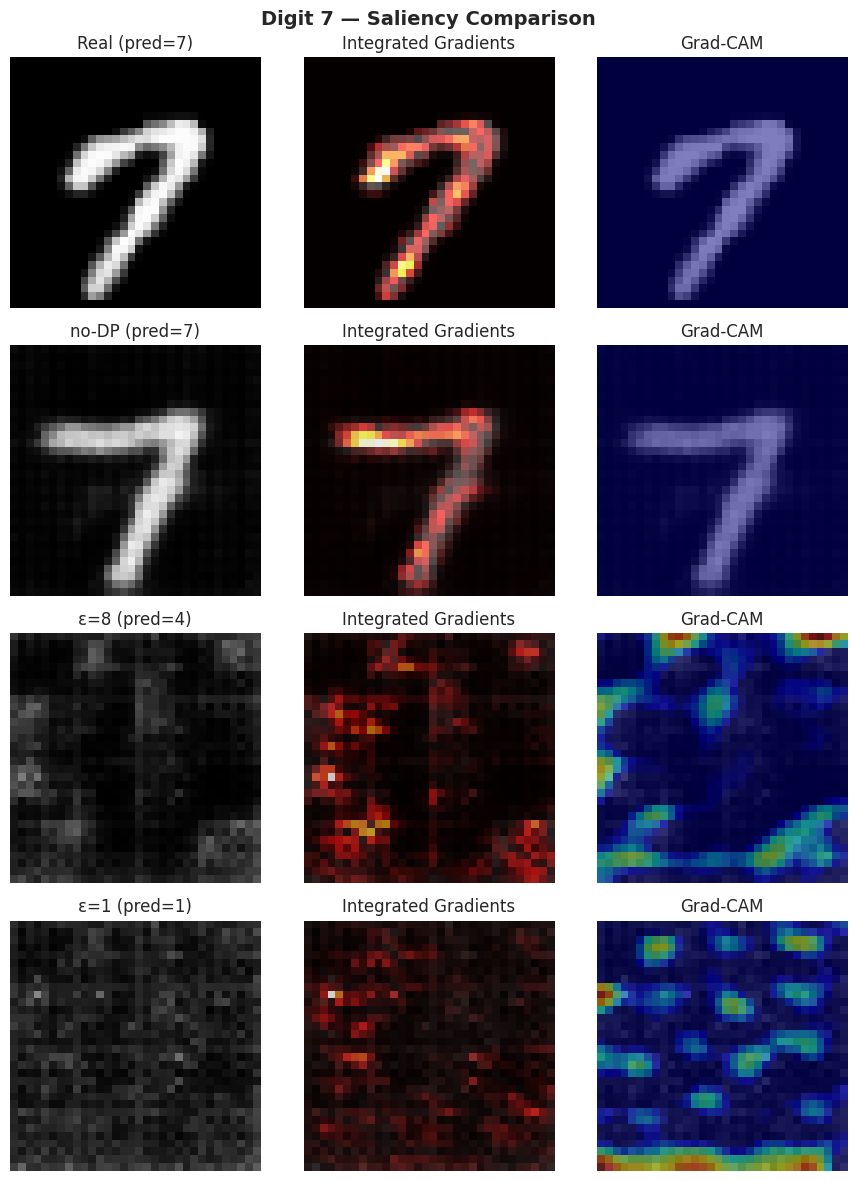

Saved per-digit saliency PDFs to visual/outputs/


In [6]:
SHOW_LABELS = [0, 1, 3, 7]  # representative digits
COND_NAMES = ["Real", "no-DP", "ε=8", "ε=1"]

clf.eval()

for digit in SHOW_LABELS:
    fig, axes = plt.subplots(len(COND_NAMES), 3, figsize=(9, 3 * len(COND_NAMES)))
    fig.suptitle(f"Digit {digit} — Saliency Comparison", fontsize=14, fontweight="bold")

    for row_idx, cond_name in enumerate(COND_NAMES):
        # Pick image
        if cond_name == "Real":
            mask = all_labels == digit
            pool = all_images[mask]
            img = pool[0]  # first real sample
        else:
            syn_x, syn_y = synthetic_cache[cond_name]
            mask = syn_y == digit
            pool = syn_x[mask]
            img = pool[0]  # first synthetic sample

        img_np = img.squeeze(0).numpy()

        # Get classifier prediction
        with torch.no_grad():
            pred = clf(img.unsqueeze(0).to(device)).argmax(1).item()
        target = digit  # attribute w.r.t. true class

        # Compute attributions
        ig_attr = normalize_attr(compute_ig(img, target))
        gc_attr = normalize_attr(compute_gradcam(img, target))

        # --- Plot ---
        # Col 0: Original image
        ax = axes[row_idx, 0]
        ax.imshow(img_np, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{cond_name} (pred={pred})")
        ax.axis("off")

        # Col 1: Integrated Gradients overlay
        ax = axes[row_idx, 1]
        ax.imshow(img_np, cmap="gray", vmin=0, vmax=1)
        ax.imshow(ig_attr, cmap="hot", alpha=0.6, vmin=0, vmax=1)
        ax.set_title("Integrated Gradients")
        ax.axis("off")

        # Col 2: Grad-CAM overlay
        ax = axes[row_idx, 2]
        ax.imshow(img_np, cmap="gray", vmin=0, vmax=1)
        ax.imshow(gc_attr, cmap="jet", alpha=0.5, vmin=0, vmax=1)
        ax.set_title("Grad-CAM")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(ROOT / "visual" / "outputs" / f"saliency_digit{digit}.pdf", bbox_inches="tight", dpi=150)
    plt.show()

print("Saved per-digit saliency PDFs to visual/outputs/")

## 5. Aggregated Saliency Comparison (All Digits)

Compact overview: one row per condition, multiple digits side by side.

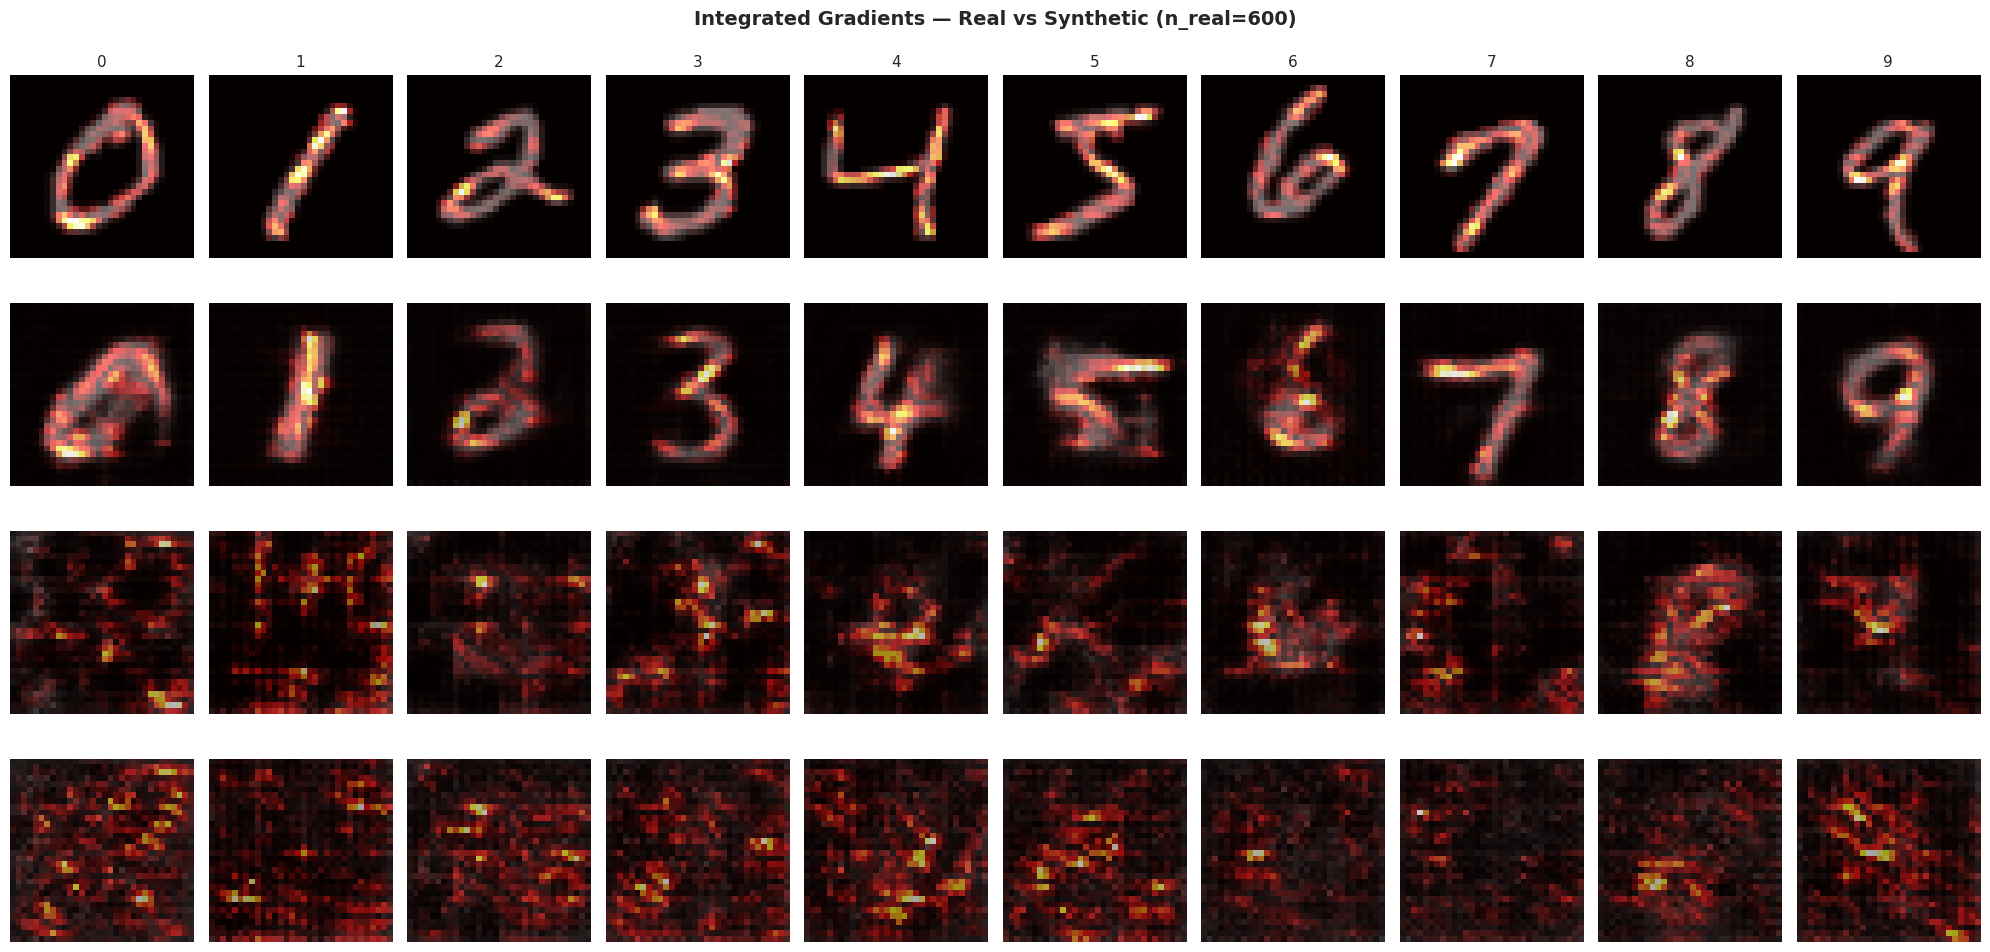

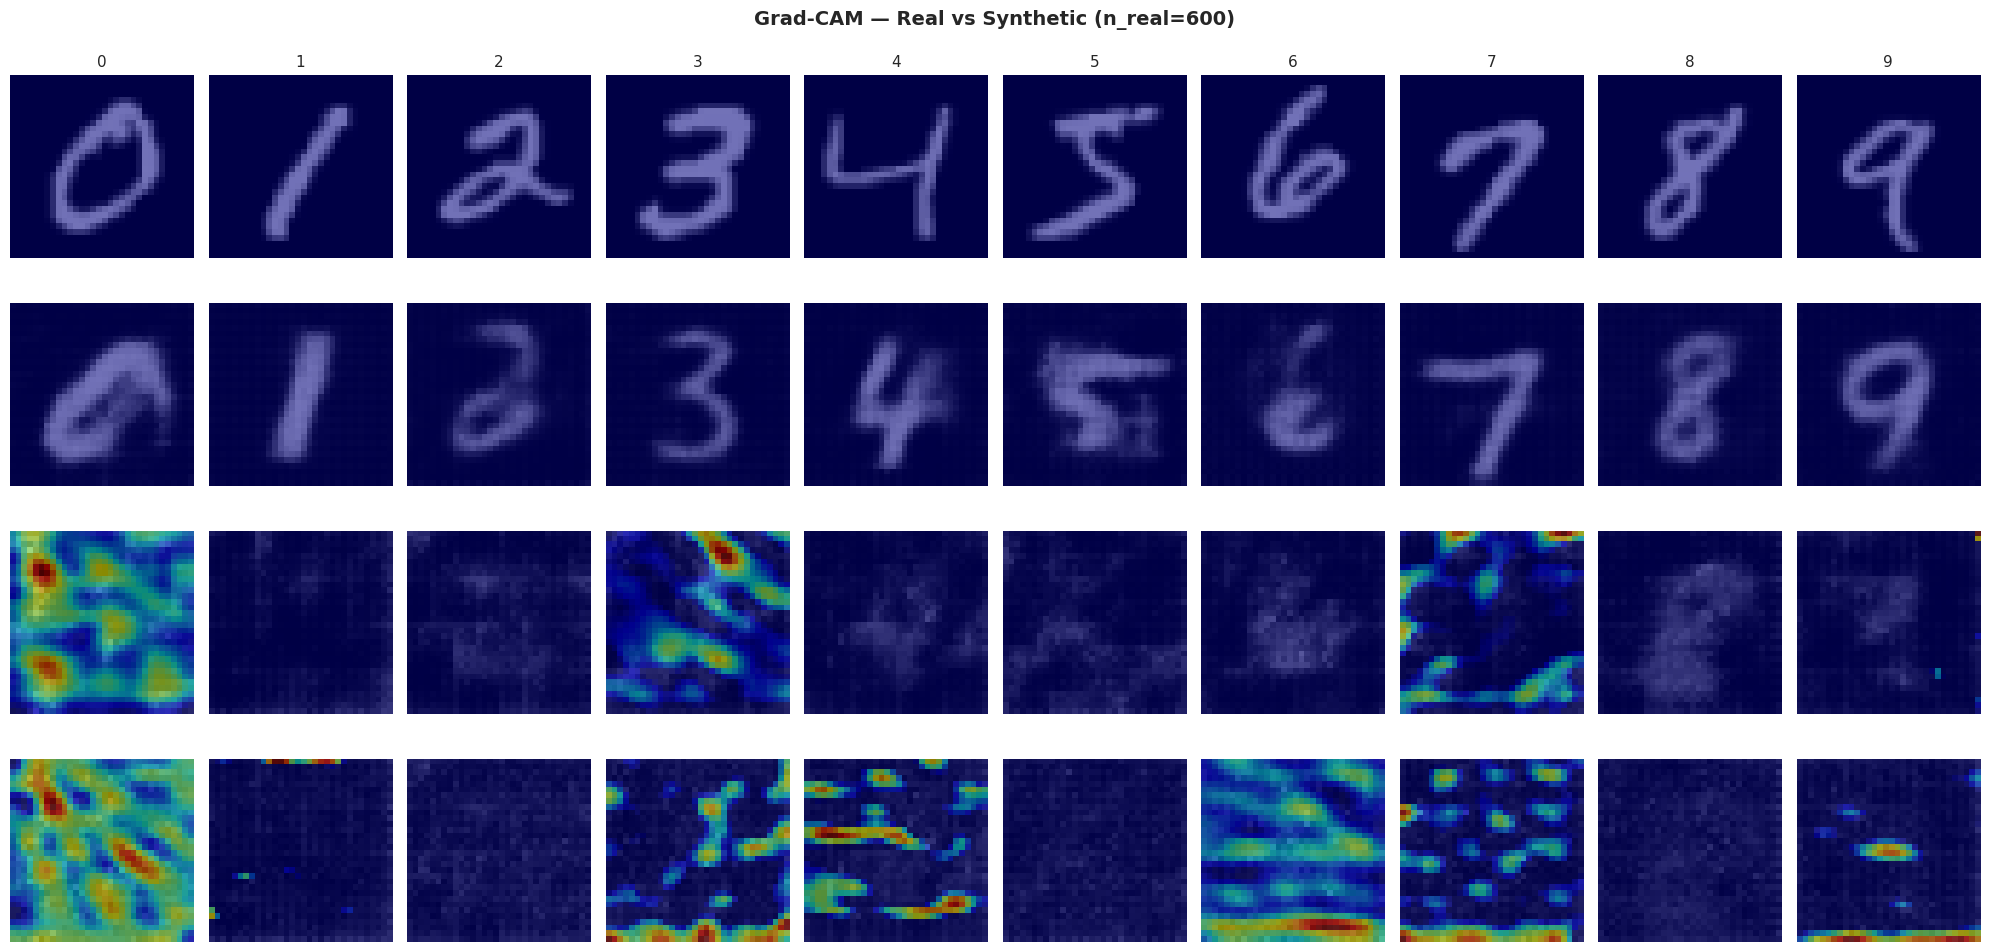

Saved overview saliency PDFs.


In [7]:
ALL_DIGITS = list(range(10))

for method_name, compute_fn in [("Integrated Gradients", compute_ig), ("Grad-CAM", compute_gradcam)]:
    fig, axes = plt.subplots(len(COND_NAMES), len(ALL_DIGITS), figsize=(2 * len(ALL_DIGITS), 2.5 * len(COND_NAMES)))
    fig.suptitle(f"{method_name} — Real vs Synthetic (n_real=600)", fontsize=14, fontweight="bold")

    cmap = "hot" if "Integrated" in method_name else "jet"

    for row_idx, cond_name in enumerate(COND_NAMES):
        for col_idx, digit in enumerate(ALL_DIGITS):
            if cond_name == "Real":
                pool = all_images[all_labels == digit]
            else:
                syn_x, syn_y = synthetic_cache[cond_name]
                pool = syn_x[syn_y == digit]

            img = pool[0]
            img_np = img.squeeze(0).numpy()
            attr = normalize_attr(compute_fn(img, digit))

            ax = axes[row_idx, col_idx]
            ax.imshow(img_np, cmap="gray", vmin=0, vmax=1)
            ax.imshow(attr, cmap=cmap, alpha=0.55, vmin=0, vmax=1)
            ax.axis("off")

            if row_idx == 0:
                ax.set_title(str(digit), fontsize=11)
            if col_idx == 0:
                ax.set_ylabel(cond_name, fontsize=10, rotation=0, labelpad=40)

    plt.tight_layout()
    fname = method_name.lower().replace(" ", "_").replace("-", "")
    plt.savefig(ROOT / "visual" / "outputs" / f"saliency_overview_{fname}.pdf", bbox_inches="tight", dpi=150)
    plt.show()

print("Saved overview saliency PDFs.")

## 6. Quantitative: Classifier Confidence on Synthetic Data

How confident is the real-trained classifier on synthetic images? This complements the visual saliency.

 no-DP: acc=0.9825, mean_conf=0.9738, median_conf=0.9997
   ε=8: acc=0.2865, mean_conf=0.2382, median_conf=0.0990
   ε=1: acc=0.1370, mean_conf=0.1126, median_conf=0.0821


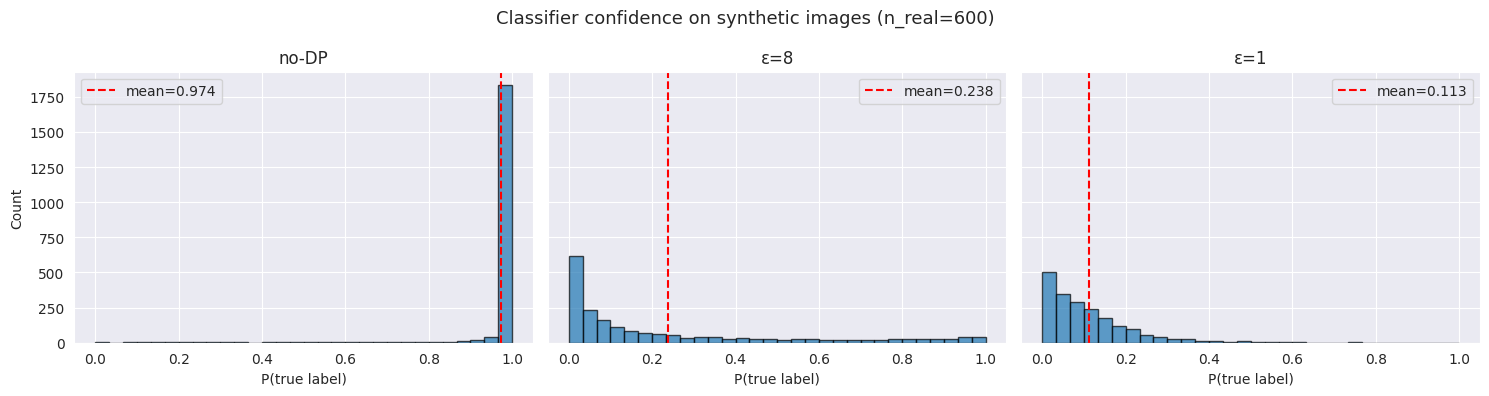

In [8]:
clf.eval()
results = []

for cond_name in ["no-DP", "ε=8", "ε=1"]:
    syn_x, syn_y = synthetic_cache[cond_name]
    with torch.no_grad():
        logits = clf(syn_x.to(device))
        probs = F.softmax(logits, dim=1)
        preds = logits.argmax(1).cpu()
        # Confidence for the TRUE label
        true_conf = probs[torch.arange(len(syn_y)), syn_y].cpu()
        acc = (preds == syn_y).float().mean().item()

    results.append({
        "condition": cond_name,
        "accuracy": acc,
        "mean_true_conf": true_conf.mean().item(),
        "median_true_conf": true_conf.median().item(),
    })
    print(f"{cond_name:>6s}: acc={acc:.4f}, mean_conf={true_conf.mean():.4f}, median_conf={true_conf.median():.4f}")

# Confidence distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, cond_name in zip(axes, ["no-DP", "ε=8", "ε=1"]):
    syn_x, syn_y = synthetic_cache[cond_name]
    with torch.no_grad():
        probs = F.softmax(clf(syn_x.to(device)), dim=1)
        true_conf = probs[torch.arange(len(syn_y)), syn_y].cpu().numpy()
    ax.hist(true_conf, bins=30, range=(0, 1), edgecolor="black", alpha=0.7)
    ax.set_title(f"{cond_name}")
    ax.set_xlabel("P(true label)")
    ax.axvline(np.mean(true_conf), color="red", linestyle="--", label=f"mean={np.mean(true_conf):.3f}")
    ax.legend()

axes[0].set_ylabel("Count")
fig.suptitle("Classifier confidence on synthetic images (n_real=600)", fontsize=13)
plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "saliency_confidence_hist.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 7. Mean Saliency Maps (Averaged Over All Samples)

Average Integrated Gradients attribution across all synthetic images per condition to show
how DP noise systematically degrades the spatial signal that the classifier relies on.

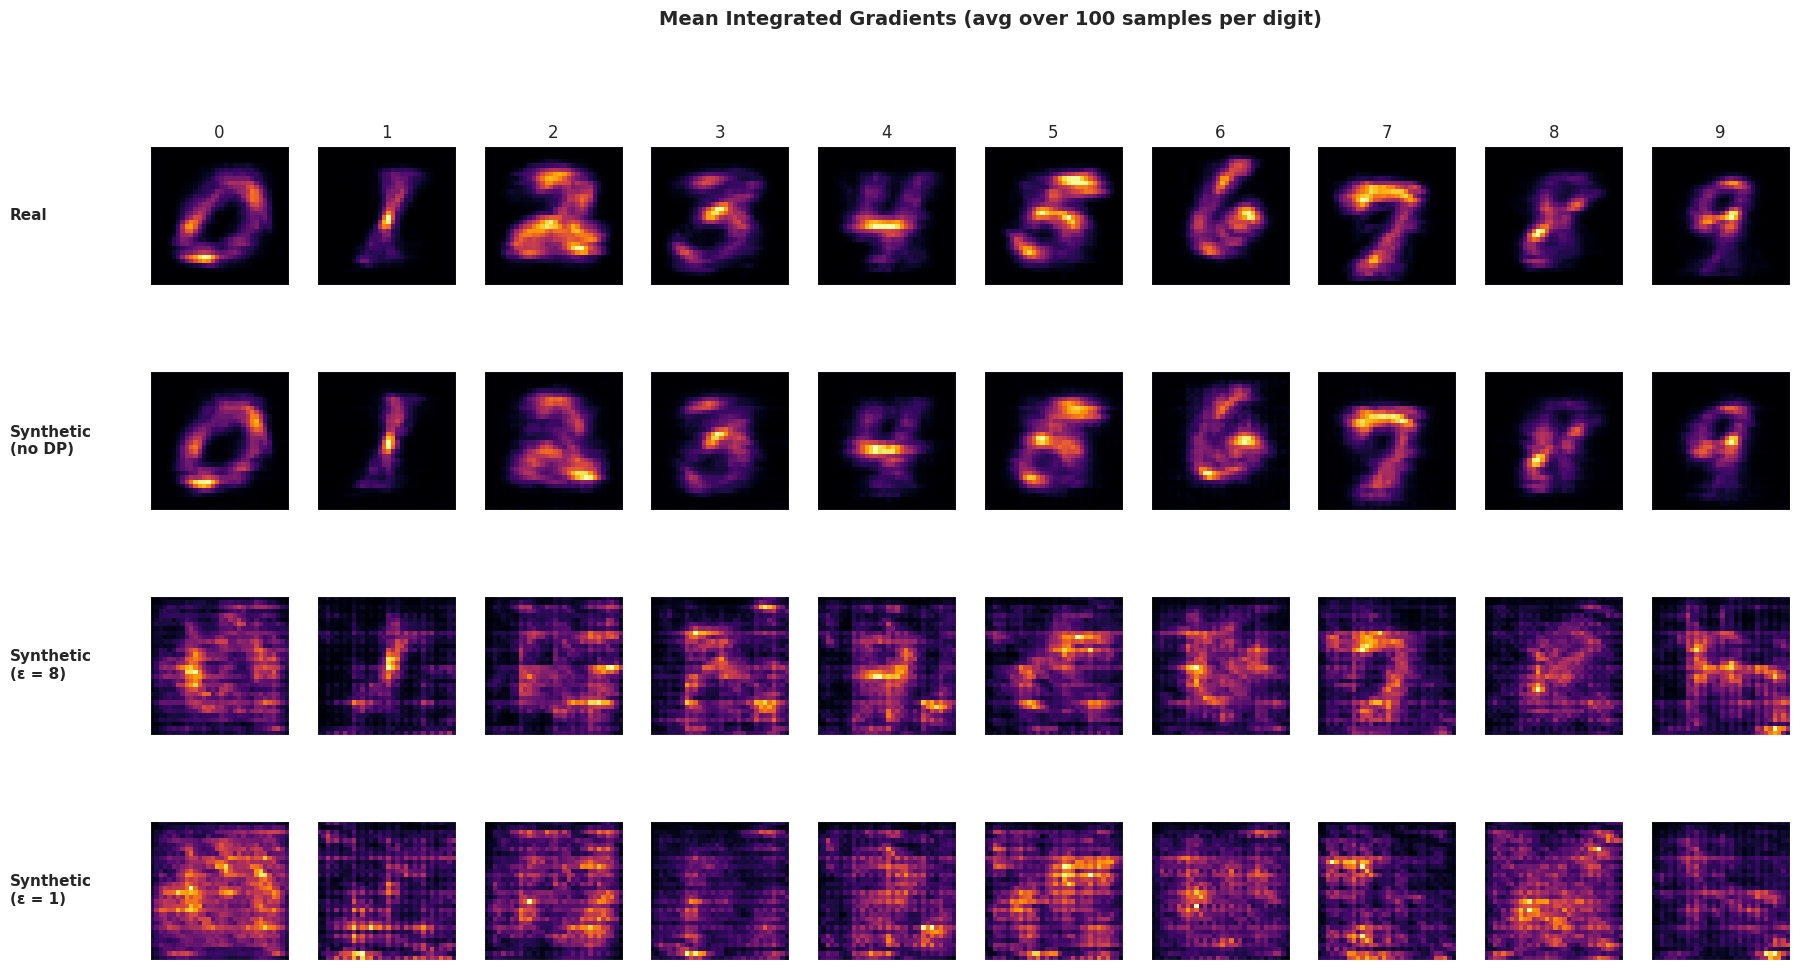

Saved mean IG saliency map.


In [15]:
N_SAMPLES = 100  # average over this many per digit

ROW_LABELS = ["Real", "Synthetic\n(no DP)", "Synthetic\n(ε = 8)", "Synthetic\n(ε = 1)"]

fig, axes = plt.subplots(
    len(COND_NAMES), 10,
    figsize=(20, 2.8 * len(COND_NAMES)),
    gridspec_kw={"left": 0.08},
)
fig.suptitle(
    f"Mean Integrated Gradients (avg over {N_SAMPLES} samples per digit)",
    fontsize=14, fontweight="bold", y=0.98,
)

for row_idx, cond_name in enumerate(COND_NAMES):
    for digit in range(10):
        if cond_name == "Real":
            pool = all_images[all_labels == digit]
        else:
            syn_x, syn_y = synthetic_cache[cond_name]
            pool = syn_x[syn_y == digit]

        n = min(N_SAMPLES, pool.shape[0])
        attrs = []
        for i in range(n):
            attrs.append(compute_ig(pool[i], digit))
        mean_attr = normalize_attr(np.mean(attrs, axis=0))

        ax = axes[row_idx, digit]
        ax.imshow(mean_attr, cmap="inferno", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if row_idx == 0:
            ax.set_title(str(digit), fontsize=12)

    # Row label via fig.text — placed to the left of the first subplot
    bbox = axes[row_idx, 0].get_position()
    fig.text(
        0.01, (bbox.y0 + bbox.y1) / 2, ROW_LABELS[row_idx],
        fontsize=11, fontweight="bold", va="center", ha="left",
    )

plt.savefig(ROOT / "visual" / "outputs" / "saliency_mean_ig.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved mean IG saliency map.")

## 8. Downstream Utility: Train on Synthetic, Test on Real

**The metric that actually matters for DP-FedAug:** If a classifier trained *only* on
synthetic data can still classify real test images, the synthetic data retains useful
information — even if it looks noisy to humans or fails fidelity metrics.

This mirrors the federated setting: clients receive synthetic data from the server and
use it to improve their local classifiers. We test multiple scenarios:
- **Real-only baseline:** Train on 600 real samples per label (upper bound)
- **Synthetic-only:** Train on synthetic data from each condition
- **Real + Synthetic (augmented):** Mimics DP-FedAug where real local data is augmented

We also vary the amount of real data to simulate extreme heterogeneity.

In [10]:
def train_and_eval(train_x, train_y, test_loader, epochs=10, lr=1e-3):
    """Train a fresh MNIST_CNN and return test accuracy."""
    model = MNIST_CNN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    ds = TensorDataset(train_x, train_y)
    dl = DataLoader(ds, batch_size=64, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            F.cross_entropy(model(xb), yb).backward()
            opt.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / total


# ── 8a. Synthetic-only classifiers ──────────────────────────────────
print("=" * 60)
print("SYNTHETIC-ONLY: Train classifier on synthetic data, test on real")
print("=" * 60)

syn_only_results = {}
for cond_name in ["no-DP", "ε=8", "ε=1"]:
    syn_x, syn_y = synthetic_cache[cond_name]
    acc = train_and_eval(syn_x, syn_y, test_loader, epochs=10)
    syn_only_results[cond_name] = acc
    print(f"  {cond_name:>6s}-only → test acc: {acc:.4f}")

# Real-only baseline (same 600 per label used for VAE training)
real_acc = train_and_eval(data_tensor, label_tensor, test_loader, epochs=10)
syn_only_results["Real (600/lbl)"] = real_acc
print(f"  {'Real':>6s} (600/label) → test acc: {real_acc:.4f}")


# ── 8b. Augmented classifiers (real + synthetic) ───────────────────
# Simulate extreme heterogeneity: client has only a FEW real samples per label
# but receives synthetic data from server redistribution
print(f"\n{'=' * 60}")
print("AUGMENTED: Few real samples + synthetic augmentation")
print("=" * 60)

aug_results = []
for n_real_local in [10, 50, 100]:
    # Subsample limited real data
    local_imgs, local_lbls = [], []
    for lbl in range(10):
        pool = real_by_label[lbl]
        perm = torch.randperm(pool.shape[0])[:n_real_local]
        local_imgs.append(pool[perm])
        local_lbls.append(torch.full((n_real_local,), lbl, dtype=torch.long))
    local_x = torch.cat(local_imgs)
    local_y = torch.cat(local_lbls)

    # Real-only baseline with limited data
    acc_real = train_and_eval(local_x, local_y, test_loader, epochs=10)
    aug_results.append({"n_real": n_real_local, "condition": "Real only", "acc": acc_real})
    print(f"\n  n_real={n_real_local}/label:")
    print(f"    Real only           → {acc_real:.4f}")

    # Augmented with each synthetic condition
    for cond_name in ["no-DP", "ε=8", "ε=1"]:
        syn_x, syn_y = synthetic_cache[cond_name]
        aug_x = torch.cat([local_x, syn_x])
        aug_y = torch.cat([local_y, syn_y])
        acc_aug = train_and_eval(aug_x, aug_y, test_loader, epochs=10)
        aug_results.append({"n_real": n_real_local, "condition": f"+ {cond_name} syn", "acc": acc_aug})
        delta_pct = (acc_aug - acc_real) * 100
        arrow = "↑" if delta_pct > 0 else "↓"
        print(f"    + {cond_name:>5s} synthetic → {acc_aug:.4f}  ({arrow}{abs(delta_pct):.1f}pp)")

SYNTHETIC-ONLY: Train classifier on synthetic data, test on real
   no-DP-only → test acc: 0.9360
     ε=8-only → test acc: 0.7331
     ε=1-only → test acc: 0.2327
    Real (600/label) → test acc: 0.9770

AUGMENTED: Few real samples + synthetic augmentation

  n_real=10/label:
    Real only           → 0.6349
    + no-DP synthetic → 0.9386  (↑30.4pp)
    +   ε=8 synthetic → 0.7805  (↑14.6pp)
    +   ε=1 synthetic → 0.6999  (↑6.5pp)

  n_real=50/label:
    Real only           → 0.9166
    + no-DP synthetic → 0.9115  (↓0.5pp)
    +   ε=8 synthetic → 0.8643  (↓5.2pp)
    +   ε=1 synthetic → 0.8923  (↓2.4pp)

  n_real=100/label:
    Real only           → 0.9392
    + no-DP synthetic → 0.9481  (↑0.9pp)
    +   ε=8 synthetic → 0.9330  (↓0.6pp)
    +   ε=1 synthetic → 0.9205  (↓1.9pp)


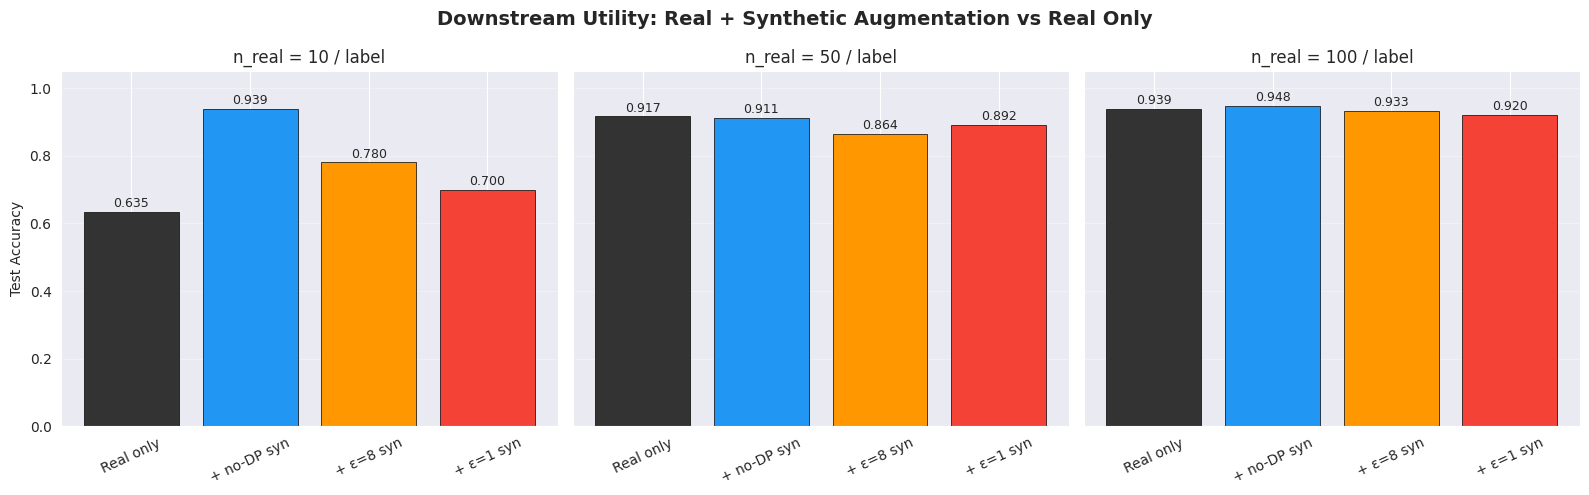

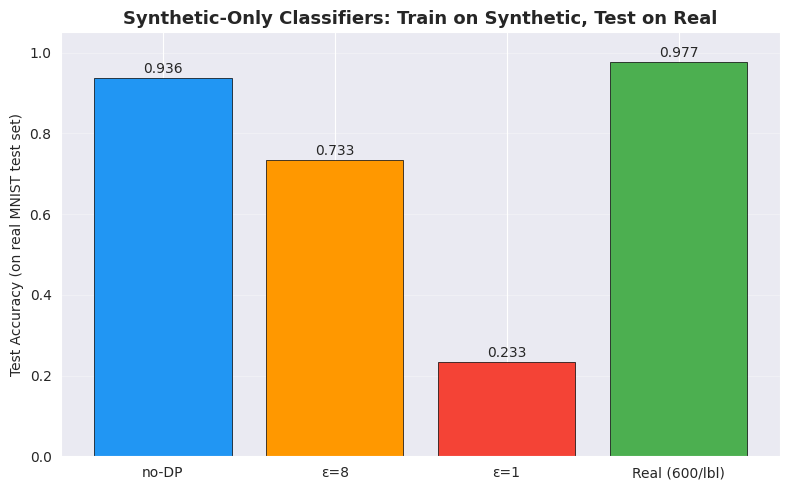


Saved downstream utility plots.


In [11]:
# ── 8c. Visualization ───────────────────────────────────────────────
import pandas as pd

aug_df = pd.DataFrame(aug_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax_idx, n_real_local in enumerate([10, 50, 100]):
    ax = axes[ax_idx]
    subset = aug_df[aug_df["n_real"] == n_real_local]

    colors = {"Real only": "#333333", "+ no-DP syn": "#2196F3", "+ ε=8 syn": "#FF9800", "+ ε=1 syn": "#F44336"}
    bars = ax.bar(subset["condition"], subset["acc"], color=[colors[c] for c in subset["condition"]],
                  edgecolor="black", linewidth=0.5)

    # Add value labels on bars
    for bar, val in zip(bars, subset["acc"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(f"n_real = {n_real_local} / label", fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Test Accuracy" if ax_idx == 0 else "")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Downstream Utility: Real + Synthetic Augmentation vs Real Only", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "saliency_downstream_utility.pdf", bbox_inches="tight", dpi=150)
plt.show()

# ── 8d. Synthetic-only bar chart ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
names = list(syn_only_results.keys())
accs = list(syn_only_results.values())
colors_syn = ["#2196F3", "#FF9800", "#F44336", "#4CAF50"]
bars = ax.bar(names, accs, color=colors_syn, edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Test Accuracy (on real MNIST test set)")
ax.set_title("Synthetic-Only Classifiers: Train on Synthetic, Test on Real", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "saliency_synonly_utility.pdf", bbox_inches="tight", dpi=150)
plt.show()

print("\nSaved downstream utility plots.")

## 9. Extreme Heterogeneity Simulation

**This is the scenario that makes DP-FedAug shine.** In extreme partitioning,
each client has data from only 1-2 classes. Without augmentation, the local
classifier can never learn the missing classes. Synthetic data — even noisy DP
synthetic data — provides the *only* signal for those missing classes.

We simulate: Client has 60 real samples of **only digit 0**, then receives
200 synthetic samples per label from the server (covering all 10 classes).

Local only (digit 0, n=60): test acc = 0.0980
  (Expected ~10% since it can only predict class 0)

+ no-DP synthetic: test acc = 0.9283  (↑83.0pp vs local-only)
+   ε=8 synthetic: test acc = 0.7513  (↑65.3pp vs local-only)
+   ε=1 synthetic: test acc = 0.1363  (↑3.8pp vs local-only)


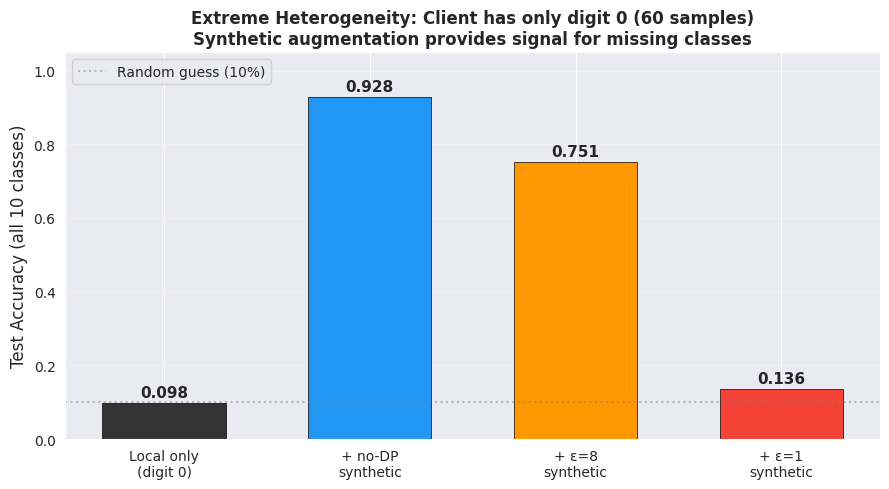


This demonstrates why DP-FedAug works despite low fidelity metrics:
Even noisy synthetic data provides crucial label coverage.


In [12]:
# ── 9a. Simulate extreme partitioning ───────────────────────────────
# Client has ONLY digit 0 (like extreme non-IID in your federated experiments)

extreme_results = []
CLIENT_DIGIT = 0
N_LOCAL = 60  # roughly total_n=600 / 10 clients

# Local data: only one class
local_x = real_by_label[CLIENT_DIGIT][:N_LOCAL]
local_y = torch.full((N_LOCAL,), CLIENT_DIGIT, dtype=torch.long)

# Baseline: train on local data only (can only predict class 0)
acc_local = train_and_eval(local_x, local_y, test_loader, epochs=10)
extreme_results.append(("Local only\n(digit 0)", acc_local))
print(f"Local only (digit {CLIENT_DIGIT}, n={N_LOCAL}): test acc = {acc_local:.4f}")
print(f"  (Expected ~10% since it can only predict class {CLIENT_DIGIT})\n")

# Augmented with synthetic data from each condition
for cond_name in ["no-DP", "ε=8", "ε=1"]:
    syn_x, syn_y = synthetic_cache[cond_name]
    aug_x = torch.cat([local_x, syn_x])
    aug_y = torch.cat([local_y, syn_y])
    acc_aug = train_and_eval(aug_x, aug_y, test_loader, epochs=10)
    extreme_results.append((f"+ {cond_name}\nsynthetic", acc_aug))
    delta = (acc_aug - acc_local) * 100
    print(f"+ {cond_name:>5s} synthetic: test acc = {acc_aug:.4f}  (↑{delta:.1f}pp vs local-only)")

# ── 9b. Plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
names = [r[0] for r in extreme_results]
accs = [r[1] for r in extreme_results]
colors_ext = ["#333333", "#2196F3", "#FF9800", "#F44336"]
bars = ax.bar(names, accs, color=colors_ext, edgecolor="black", linewidth=0.5, width=0.6)

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Test Accuracy (all 10 classes)", fontsize=12)
ax.set_title(
    f"Extreme Heterogeneity: Client has only digit {CLIENT_DIGIT} ({N_LOCAL} samples)\n"
    "Synthetic augmentation provides signal for missing classes",
    fontsize=12, fontweight="bold"
)
ax.set_ylim(0, 1.05)
ax.axhline(0.1, color="gray", linestyle=":", alpha=0.5, label="Random guess (10%)")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / "visual" / "outputs" / "saliency_extreme_hetero.pdf", bbox_inches="tight", dpi=150)
plt.show()

print("\nThis demonstrates why DP-FedAug works despite low fidelity metrics:")
print("Even noisy synthetic data provides crucial label coverage.")